# Miniproject 1 — Architecture 2: Overfitting CNN

**Team Members:** Aurel Köppel, Yves Fricker

**Course:** Applications of AI (AiAp), OST, Spring 2026

---

In this notebook we define and train a **complex CNN** on the same Animals-10 dataset as in Notebook 1. The model has significantly more layers, filters, and parameters. The goal is to demonstrate **overfitting**: the model memorizes the training data and generalizes poorly to unseen data.

## 1. Imports and Setup

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Set Keras backend to TensorFlow
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

# Import our shared helper functions
from helpers import (
    load_animals10,
    split_data,
    plot_learning_curves,
    plot_confusion_matrices,
    print_classification_metrics,
)

print(f"Keras version: {keras.__version__}")
print(f"Backend: {keras.backend.backend()}")

Keras version: 3.13.2
Backend: tensorflow


In [10]:
import kagglehub
import os

# Download dataset automatically (cached after first download)
path = kagglehub.dataset_download("alessiocorrado99/animals10")
DATA_DIR = os.path.join(path, "raw-img")

X, y, class_names = load_animals10(
    data_dir=DATA_DIR,
    img_size=64,
    samples_per_class=1000,
    reduced_class="elefante",
    reduced_count=150,
    seed=42,
)

X_trainval, X_test, y_trainval, y_test = split_data(X, y, test_size=0.3, random_state=42)

NUM_CLASSES = len(class_names)
IMG_SIZE = 64

print(f"\nClasses: {class_names}")
print(f"Train+Val: {X_trainval.shape}, Test: {X_test.shape}")

  Loaded 1000 images for class 'dog' (folder: cane)
  Loaded 1000 images for class 'horse' (folder: cavallo)
  Loaded 150 images for class 'elephant' (folder: elefante)
  Loaded 1000 images for class 'butterfly' (folder: farfalla)
  Loaded 1000 images for class 'chicken' (folder: gallina)
  Loaded 1000 images for class 'cat' (folder: gatto)
  Loaded 1000 images for class 'cow' (folder: mucca)
  Loaded 1000 images for class 'sheep' (folder: pecora)
  Loaded 1000 images for class 'spider' (folder: ragno)
  Loaded 1000 images for class 'squirrel' (folder: scoiattolo)

Total: 9150 images, 10 classes
Train+Val: 6405 samples
Test:      2745 samples (locked away)

Classes: ['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'spider', 'squirrel']
Train+Val: (6405, 64, 64, 3), Test: (2745, 64, 64, 3)


## 3. Model Definition — Complex CNN (Overfitting)

We build a much larger CNN with **6 trainable layers** and approximately **768,000 parameters**.

**Architecture:**
- 4 convolutional blocks, each with increasing number of filters (32 → 64 → 128 → 128)
- Each block: `Conv2D` + `ReLU` + `MaxPooling2D`
- Flatten → Dense(256) → Dense(10)

**Why this will overfit:**
- ~768K parameters is **much more** than needed for our relatively small dataset (~6400 training samples).
- The model has enough capacity to **memorize** the training data, including noise.
- Without any regularization, the model fits the training data perfectly but fails on unseen data.

**Comparison with Architecture 1:**

| | Architecture 1 | Architecture 2 |
|---|---|---|
| Trainable layers | 3 | 6 |
| Parameters | ~1,700 | ~768,000 |
| Filters | 4, 8 | 32, 64, 128, 128 |
| Dense neurons | 0 (direct to output) | 256 |

In [12]:
model = keras.Sequential([
    keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Block 1: 32 filters — detects basic patterns (edges, textures)
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),  # 64x64 -> 32x32

    # Block 2: 64 filters — combines basic patterns into more complex features
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),  # 32x32 -> 16x16

    # Block 3: 128 filters — higher-level features (parts of animals)
    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),  # 16x16 -> 8x8

    # Block 4: 128 filters — most abstract features
    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),  # 8x8 -> 4x4

    # Classification head
    layers.Flatten(),          # 4 * 4 * 128 = 2048
    layers.Dense(256, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax"),
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 8, 8, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 767,946 (2.93 MB)

 Trainable params: 767,946 (2.93 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
total_params = model.count_params()
print(f"\nTotal trainable parameters: {total_params:,}")
print(f"This is about {total_params / 1698:.0f}x more than Architecture 1.")


Total trainable parameters: 767,946
This is about 452x more than Architecture 1.


## 4. Compile and Train

We use the same settings as Architecture 1 for a fair comparison:
- Optimizer: Adam
- Loss: sparse_categorical_crossentropy
- 50 epochs, batch_size=32
- validation_split=0.2

In [14]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    X_trainval,
    y_trainval,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)

Epoch 1/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.2131 - loss: 2.1034 - val_accuracy: 0.2506 - val_loss: 2.0255
Epoch 2/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.3273 - loss: 1.8476 - val_accuracy: 0.3646 - val_loss: 1.7758
Epoch 3/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.3923 - loss: 1.6902 - val_accuracy: 0.4028 - val_loss: 1.6248
Epoch 4/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.4696 - loss: 1.4865 - val_accuracy: 0.4754 - val_loss: 1.4781
Epoch 5/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.5379 - loss: 1.3186 - val_accuracy: 0.4848 - val_loss: 1.4792
Epoch 6/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.5886 - loss: 1.1775 - val_accuracy: 0.5074 - val_loss: 1.4430
Epoch 7/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.6475 - loss: 1.0174 - val_accuracy: 0.5082 - val_loss: 1.4604
Epoch 8/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.6981 - loss: 0.8593 - val_accu

## 5. Learning Curves

**Expected behavior for overfitting:**
- **Training loss** drops towards 0 — the model perfectly memorizes the training data.
- **Validation loss** initially decreases but then **diverges** (increases) — the model gets worse on unseen data.
- The **gap** between training and validation curves grows over time.
- Training accuracy approaches 100%, while validation accuracy plateaus or even drops.

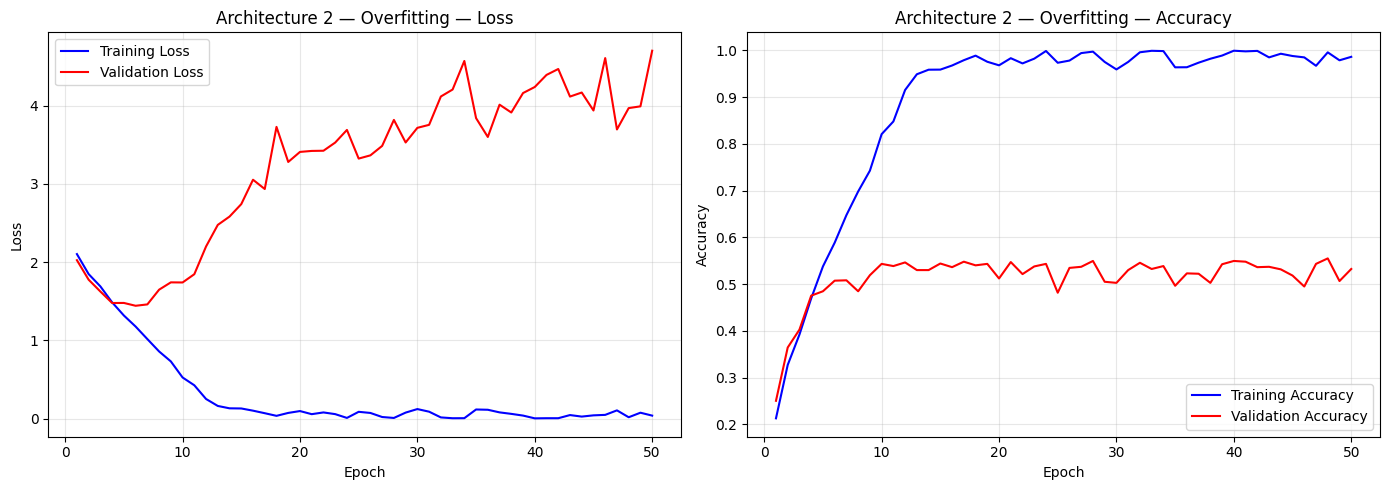

In [15]:
plot_learning_curves(history, title="Architecture 2 — Overfitting")

## 6. Confusion Matrices

In [16]:
# Extract validation set (same split as Keras uses)
val_split = int(len(X_trainval) * 0.8)
X_val = X_trainval[val_split:]
y_val = y_trainval[val_split:]

y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

print(f"Validation set size: {len(X_val)}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Validation set size: 1281


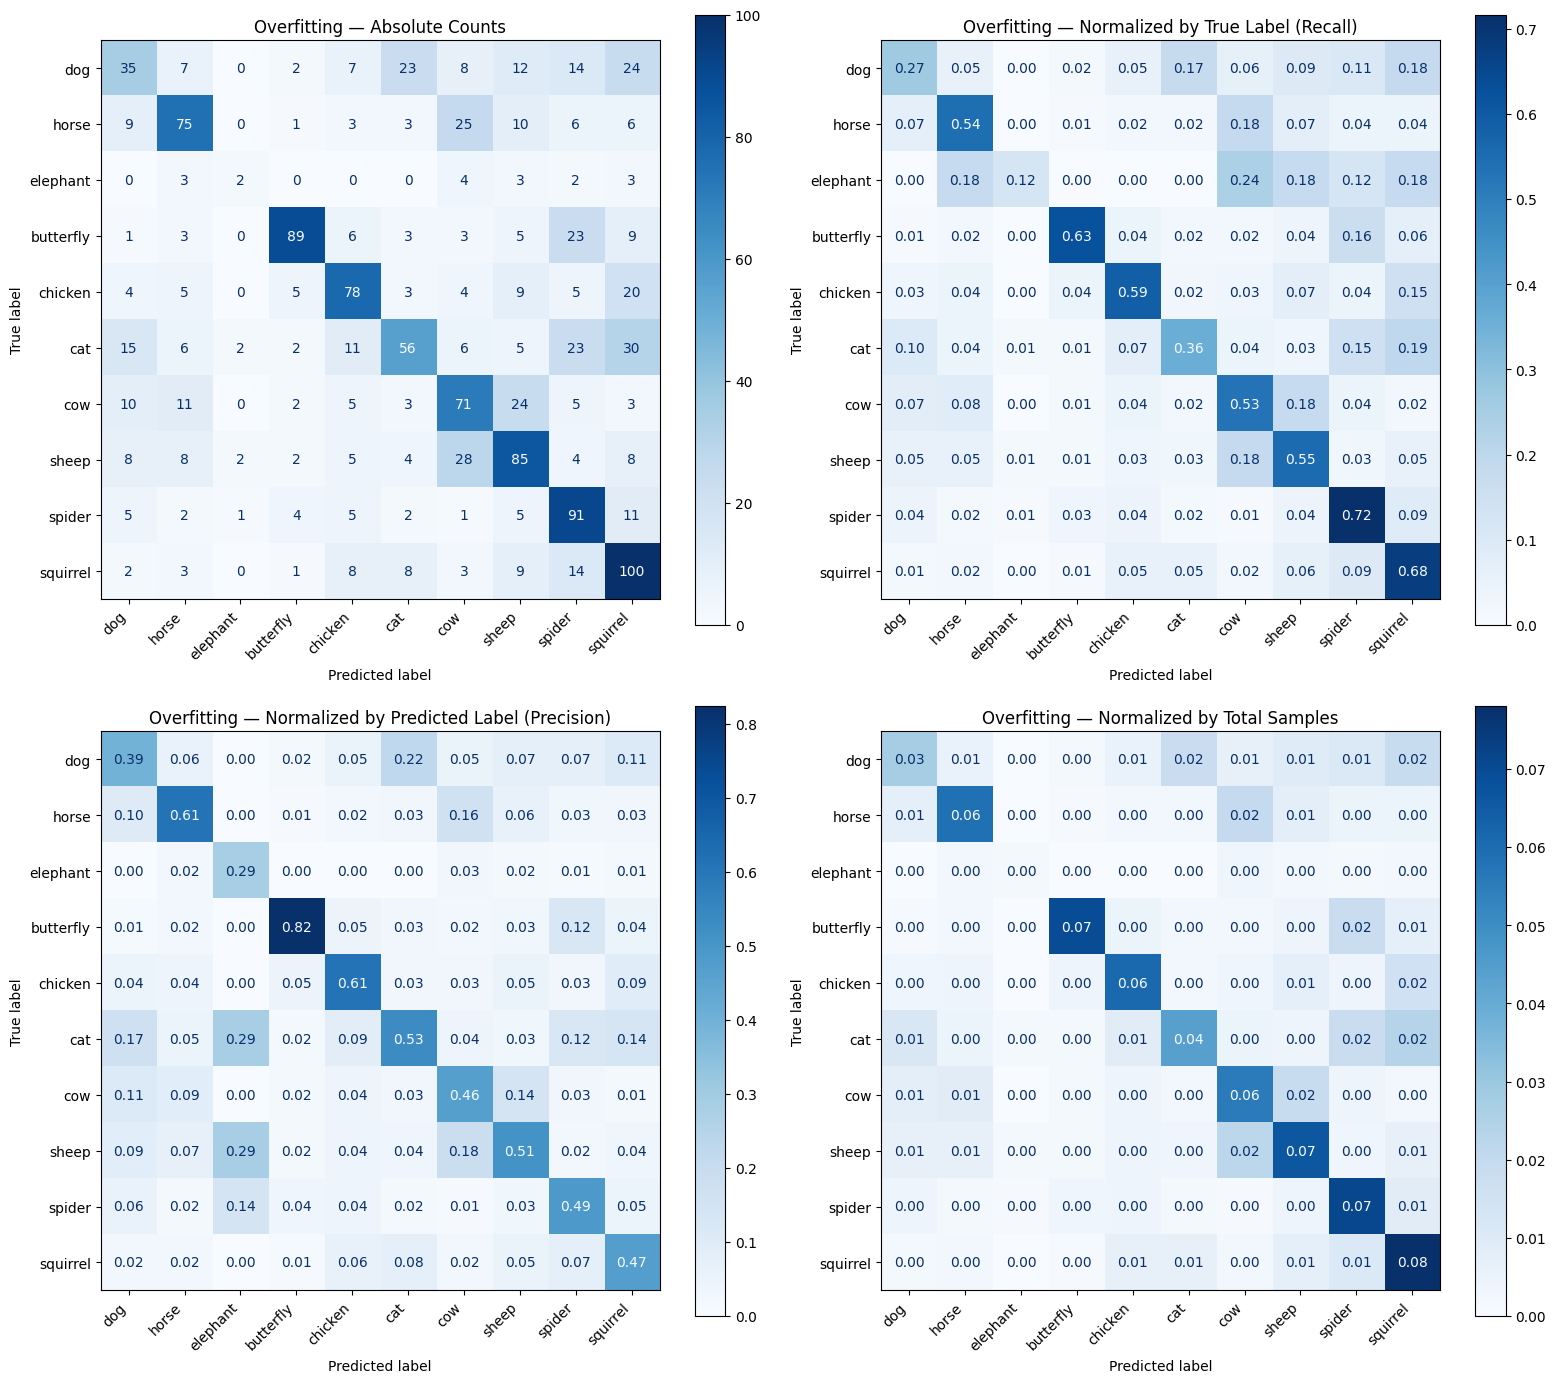

In [18]:
plot_confusion_matrices(y_val, y_pred, class_names, title_prefix="Overfitting — ")

## 7. Classification Metrics

In [19]:
print_classification_metrics(y_val, y_pred, class_names)

Classification Report:
              precision    recall  f1-score   support

         dog      0.393     0.265     0.317       132
       horse      0.610     0.543     0.575       138
    elephant      0.286     0.118     0.167        17
   butterfly      0.824     0.627     0.712       142
     chicken      0.609     0.586     0.598       133
         cat      0.533     0.359     0.429       156
         cow      0.464     0.530     0.495       134
       sheep      0.509     0.552     0.530       154
      spider      0.487     0.717     0.580       127
    squirrel      0.467     0.676     0.552       148

    accuracy                          0.532      1281
   macro avg      0.518     0.497     0.495      1281
weighted avg      0.542     0.532     0.527      1281



## 8. Discussion

### Observations:

1. **Overfitting confirmed (High Variance):** The training loss drops towards 0, meaning the model perfectly memorizes the training data. The validation loss diverges, indicating poor generalization. The growing gap between training and validation curves is the hallmark of **high variance**.

2. **Training accuracy ~100%, validation accuracy stagnant:** The model fits the training data perfectly but fails to generalize to unseen data. This confirms that the model has memorized noise and irrelevant patterns alongside useful features.

3. **Still better than Architecture 1:** Despite overfitting, the validation accuracy is higher than Architecture 1's. The model *does* learn useful representations (edges → textures → animal parts) — it just also memorizes noise. The increasing filter counts (32 → 64 → 128 → 128) follow the classic CNN pattern: early layers detect simple patterns, later layers combine them into complex features.

4. **Imbalanced class:** The "elephant" class (150 samples) shows improved but still low performance (Precision=0.286, Recall=0.118). With so few samples, the model tends to overfit to these specific examples rather than learning generalizable features for this class.

### Comparison with Architecture 1:

| Metric | Architecture 1 (Underfit) | Architecture 2 (Overfit) |
|---|---|---|
| Training Loss | High (cannot learn) | Very low (~0) |
| Validation Loss | High | Diverges |
| Train-Val Gap | Small (Low Variance) | Large (High Variance) |
| Parameters | ~1,700 | ~768,000 |
| Problem | High Bias | High Variance |

### Conclusion:

This complex model has **too much capacity** for our dataset size. It memorizes the training data instead of learning generalizable features. In Notebook 3, we will use the **same architecture** but add **regularization** (Dropout + L2) to prevent overfitting and improve generalization.